# Brain Tumor Classification — EfficientNet-B0 (From Scratch)
Pipeline: Data Loading → Model Training → Evaluation → Grad-CAM

## 1. Setup & Device

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import os
import itertools
import torch.nn.functional as F
import torchvision.transforms as T
from collections import Counter
from PIL import Image
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights
from torchvision.datasets import ImageFolder
from preprocess import ImagePreprocessor
from sklearn.metrics import confusion_matrix, classification_report

torch.manual_seed(42)

if torch.backends.mps.is_available():
    device = torch.device('mps')
elif torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')

os.makedirs('plots',  exist_ok=True)
os.makedirs('models', exist_ok=True)

print(f'Using device: {device}')

## 2. Data Loading

In [ ]:
train_data = 'brain-Tumor-1/train'
test_data  = 'brain-Tumor-1/test'
val_data   = 'brain-Tumor-1/valid'

preprocessor  = ImagePreprocessor(size=(224, 224))
train_dataset = ImageFolder(train_data, transform=preprocessor.train_transform)
test_dataset  = ImageFolder(test_data,  transform=preprocessor.test_transform)
val_dataset   = ImageFolder(val_data,   transform=preprocessor.test_transform)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader  = torch.utils.data.DataLoader(test_dataset,  batch_size=32, shuffle=False)
val_loader   = torch.utils.data.DataLoader(val_dataset,   batch_size=32, shuffle=False)

print(f'Classes : {train_dataset.classes}')
print(f'Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}')
print('Train distribution:', Counter(train_dataset.targets))
print('Val   distribution:', Counter(val_dataset.targets))
print('Test  distribution:', Counter(test_dataset.targets))

## 3. Model — EfficientNet-B0

In [ ]:
model = efficientnet_b0(weights=None)
print(model)

In [ ]:
# Replace classifier[1]: Linear(1280 -> 1000) becomes Linear(1280 -> 2)
num_classes = len(train_dataset.classes)
model.classifier[1] = torch.nn.Linear(in_features=1280, out_features=num_classes)
model = model.to(device)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Trainable parameters: {total_params:,}')
print(f'Classifier: {model.classifier}')

## 4. Training

In [ ]:
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=2, factor=0.5)
epochs    = 20

In [ ]:
def train(model, train_loader, val_loader, criterion, optimizer, epochs,
          patience=5, save_path='models/efficientnet_scratch.pt', scheduler=None):
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    best_val_loss    = float('inf')
    patience_counter = 0

    for epoch in range(1, epochs + 1):
        # ── Train ────────────────────────────────────────────────────────
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss    = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * images.size(0)
            correct      += (outputs.argmax(1) == labels).sum().item()
            total        += labels.size(0)
        train_loss = running_loss / total
        train_acc  = correct / total

        # ── Validate ─────────────────────────────────────────────────────
        model.eval()
        val_loss_sum, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs       = model(images)
                loss          = criterion(outputs, labels)
                val_loss_sum += loss.item() * images.size(0)
                val_correct  += (outputs.argmax(1) == labels).sum().item()
                val_total    += labels.size(0)
        val_loss = val_loss_sum / val_total
        val_acc  = val_correct  / val_total

        if scheduler:
            scheduler.step(val_loss)

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        print(f'Epoch [{epoch:02d}/{epochs}]  '
              f'train_loss: {train_loss:.4f}  train_acc: {train_acc:.4f}  '
              f'val_loss: {val_loss:.4f}  val_acc: {val_acc:.4f}')

        if val_loss < best_val_loss:
            best_val_loss    = val_loss
            patience_counter = 0
            torch.save(model.state_dict(), save_path)
            print(f'  ✓ Best model saved (val_loss: {best_val_loss:.4f})')
        else:
            patience_counter += 1
            print(f'  No improvement ({patience_counter}/{patience})')
            if patience_counter >= patience:
                print(f'\nEarly stopping at epoch {epoch}.')
                break

    print(f"\nDone. Best model saved to '{save_path}'")
    return history

In [ ]:
history = train(
    model        = model,
    train_loader = train_loader,
    val_loader   = val_loader,
    criterion    = criterion,
    optimizer    = optimizer,
    epochs       = epochs,
    patience     = 5,
    save_path    = 'models/efficientnet_scratch.pt',
    scheduler    = scheduler
)

Epoch [01/20]  train_loss: 0.7930  train_acc: 0.5687  val_loss: 0.6785  val_acc: 0.6222
  ✓ Best model saved (val_loss: 0.6785)
Epoch [02/20]  train_loss: 0.7253  train_acc: 0.6312  val_loss: 0.6631  val_acc: 0.6222
  ✓ Best model saved (val_loss: 0.6631)


## 5. Training Curves

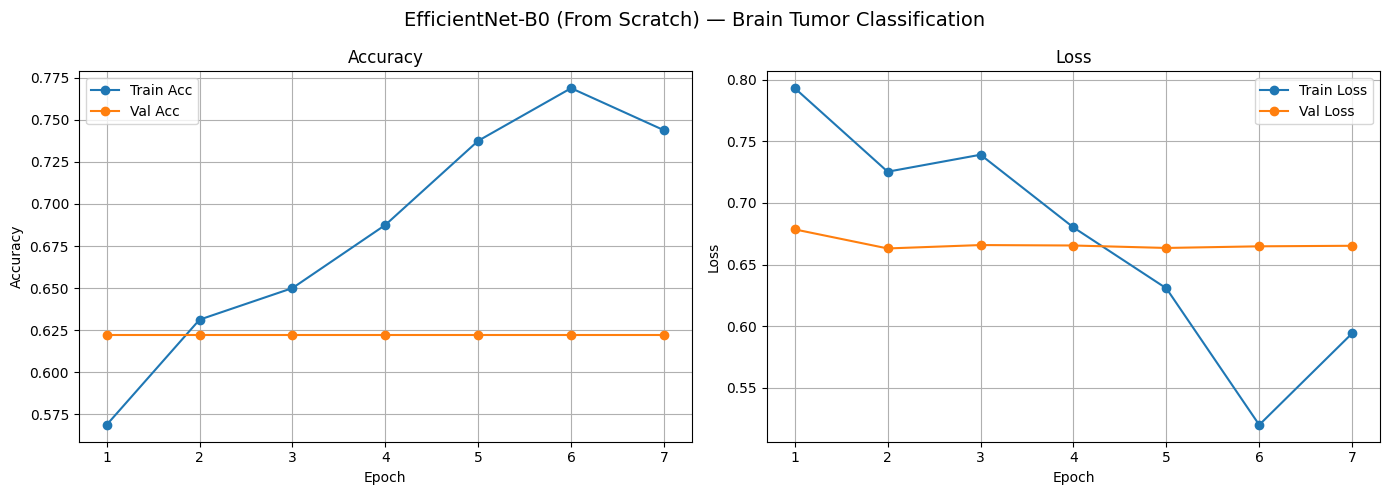

In [13]:
epochs_ran = range(1, len(history['train_loss']) + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(epochs_ran, history['train_acc'], label='Train Acc', marker='o')
ax1.plot(epochs_ran, history['val_acc'],   label='Val Acc',   marker='o')
ax1.set_title('Accuracy'); ax1.set_xlabel('Epoch'); ax1.set_ylabel('Accuracy')
ax1.legend(); ax1.grid(True)

ax2.plot(epochs_ran, history['train_loss'], label='Train Loss', marker='o')
ax2.plot(epochs_ran, history['val_loss'],   label='Val Loss',   marker='o')
ax2.set_title('Loss'); ax2.set_xlabel('Epoch'); ax2.set_ylabel('Loss')
ax2.legend(); ax2.grid(True)

plt.suptitle('EfficientNet-B0 (From Scratch) — Brain Tumor Classification', fontsize=14)
plt.tight_layout()
plt.savefig('plots/efficientnet_scratch_curves.png', dpi=150)
plt.show()

## 6. Evaluation — Test Accuracy, Confusion Matrix, Predictions

Test Accuracy: 0.6087 (14/23)

Classification Report:
              precision    recall  f1-score   support

     NoTumor       0.00      0.00      0.00         9
       Tumor       0.61      1.00      0.76        14

    accuracy                           0.61        23
   macro avg       0.30      0.50      0.38        23
weighted avg       0.37      0.61      0.46        23



C:\Users\flode\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\flode\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\flode\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


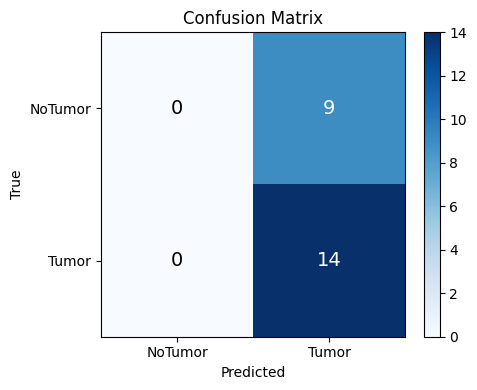

In [ ]:
model.load_state_dict(torch.load('models/efficientnet_scratch.pt', map_location=device))
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        preds = model(images).argmax(dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

test_acc = sum(p == l for p, l in zip(all_preds, all_labels)) / len(all_labels)
print(f'Test Accuracy: {test_acc:.4f} ({int(test_acc*len(all_labels))}/{len(all_labels)})')
print('\nClassification Report:')
print(classification_report(all_labels, all_preds, target_names=train_dataset.classes))

# Confusion matrix
cm_mat = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm_mat, interpolation='nearest', cmap=plt.cm.Blues)
plt.colorbar(im)
ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
ax.set_xticklabels(train_dataset.classes)
ax.set_yticklabels(train_dataset.classes)
for i, j in itertools.product(range(2), range(2)):
    ax.text(j, i, cm_mat[i, j], ha='center', va='center', fontsize=14,
            color='white' if cm_mat[i, j] > cm_mat.max() / 2 else 'black')
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
ax.set_title('Confusion Matrix')
plt.tight_layout()
#plt.savefig('plots/confusion_matrix_scratch.png', dpi=150)
plt.show()

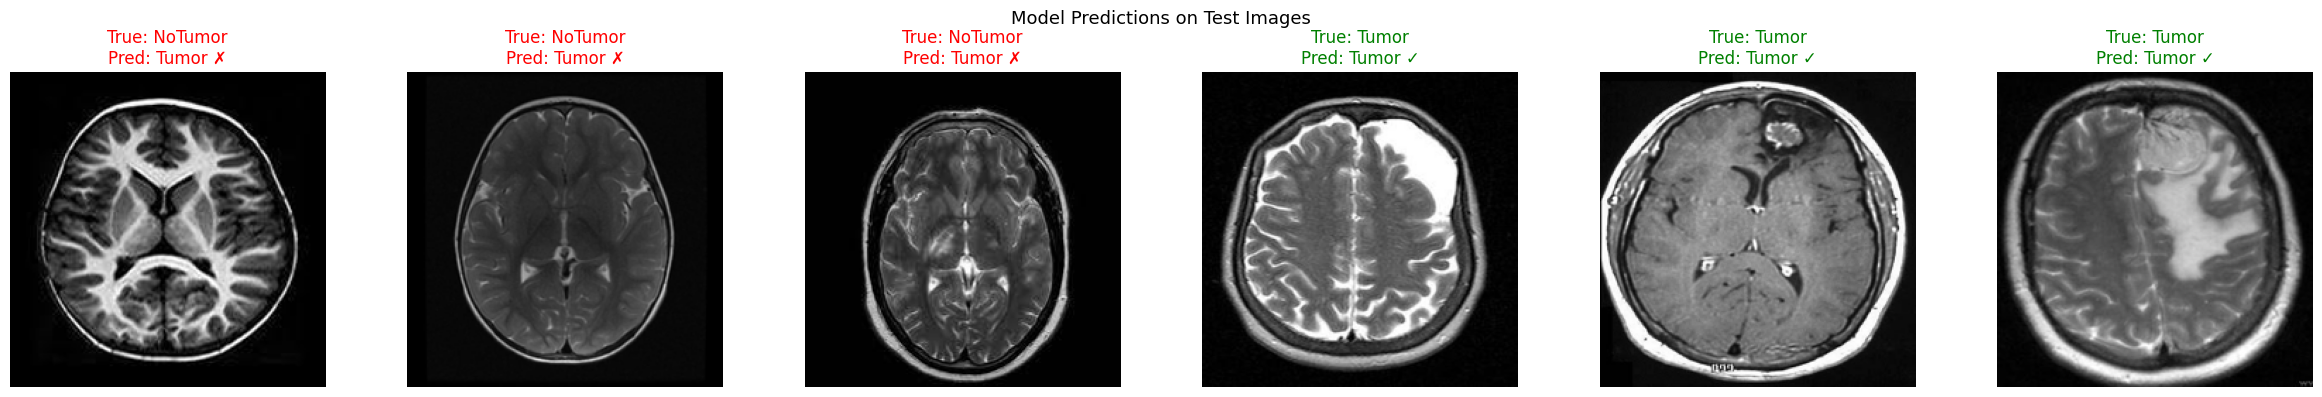

In [ ]:
# Show model predictions on sample test images
transform_single = T.Compose([
    T.Resize((224, 224)),
    T.Grayscale(num_output_channels=3),
    T.ToTensor(),
    T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

test_samples = []
for class_name in train_dataset.classes:
    class_dir = os.path.join(test_data, class_name)
    if os.path.exists(class_dir):
        for fname in os.listdir(class_dir)[:3]:
            test_samples.append((os.path.join(class_dir, fname), class_name))

fig, axes = plt.subplots(1, len(test_samples), figsize=(4 * len(test_samples), 4))
if len(test_samples) == 1:
    axes = [axes]

model.eval()
for ax, (img_path, true_label) in zip(axes, test_samples):
    pil_img    = Image.open(img_path).convert('RGB')
    tensor     = transform_single(pil_img).unsqueeze(0).to(device)
    with torch.no_grad():
        pred_idx   = model(tensor).argmax(dim=1).item()
    pred_label = train_dataset.classes[pred_idx]
    correct    = '✓' if pred_label == true_label else '✗'
    color      = 'green' if pred_label == true_label else 'red'
    ax.imshow(pil_img.resize((224, 224)))
    ax.set_title(f'True: {true_label}\nPred: {pred_label} {correct}', color=color)
    ax.axis('off')
plt.suptitle('Model Predictions on Test Images', fontsize=13)
plt.tight_layout()
#plt.savefig('plots/predictions_scratch.png', dpi=150)
plt.show()

## 7. Grad-CAM — Where does the model look?
Heatmap showing which region of the MRI the model focused on to make its decision.

In [18]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model       = model
        self.gradients   = None
        self.activations = None
        target_layer.register_forward_hook(self._save_activation)
        target_layer.register_full_backward_hook(self._save_gradient)

    def _save_activation(self, module, input, output):
        self.activations = output.detach()

    def _save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def generate(self, input_tensor, class_idx=None):
        self.model.eval()
        output = self.model(input_tensor)
        if class_idx is None:
            class_idx = output.argmax(dim=1).item()
        self.model.zero_grad()
        output[0, class_idx].backward()
        weights = self.gradients.mean(dim=(2, 3), keepdim=True)
        cam     = F.relu((weights * self.activations).sum(dim=1, keepdim=True))
        cam     = F.interpolate(cam, size=(224, 224), mode='bilinear', align_corners=False)
        cam     = cam.squeeze().cpu().numpy()
        cam     = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        return cam, class_idx

gradcam = GradCAM(model, target_layer=model.features[-1])
print('Grad-CAM ready.')

Grad-CAM ready.


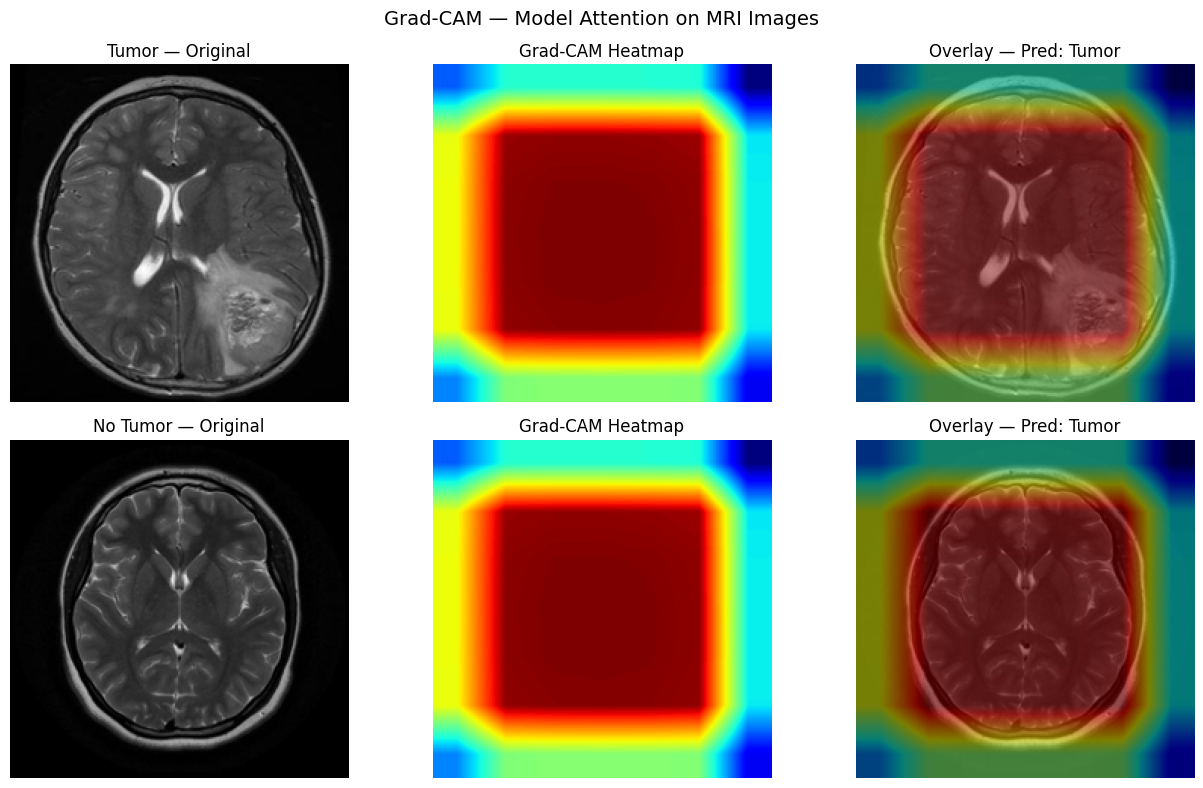

In [ ]:
def show_gradcam(img_path, gradcam, classes, ax_row=None):
    pil_img      = Image.open(img_path).convert('RGB')
    input_tensor = transform_single(pil_img).unsqueeze(0).to(device)
    input_tensor.requires_grad_(True)
    cam, pred_idx = gradcam.generate(input_tensor)
    pred_label    = classes[pred_idx]
    orig    = np.array(pil_img.resize((224, 224)))
    heatmap = (cm.jet(cam)[:, :, :3] * 255).astype(np.uint8)
    overlay = (0.5 * orig + 0.5 * heatmap).astype(np.uint8)
    return orig, cam, overlay, pred_label

fig, axes = plt.subplots(2, 3, figsize=(13, 8))
tumor_path   = os.path.join(train_data, 'Tumor',   os.listdir(os.path.join(train_data, 'Tumor'))[0])
notumor_path = os.path.join(train_data, 'NoTumor', os.listdir(os.path.join(train_data, 'NoTumor'))[0])

for row, (img_path, label) in enumerate([(tumor_path, 'Tumor'), (notumor_path, 'No Tumor')]):
    orig, cam_map, overlay, pred = show_gradcam(img_path, gradcam, train_dataset.classes)
    axes[row][0].imshow(orig);              axes[row][0].set_title(f'{label} — Original');   axes[row][0].axis('off')
    axes[row][1].imshow(cam_map, cmap='jet'); axes[row][1].set_title('Grad-CAM Heatmap');    axes[row][1].axis('off')
    axes[row][2].imshow(overlay);           axes[row][2].set_title(f'Overlay — Pred: {pred}'); axes[row][2].axis('off')
plt.suptitle('Grad-CAM — Model Attention on MRI Images', fontsize=14)
plt.tight_layout()
#plt.savefig('plots/gradcam_scratch.png', dpi=150)
plt.show()

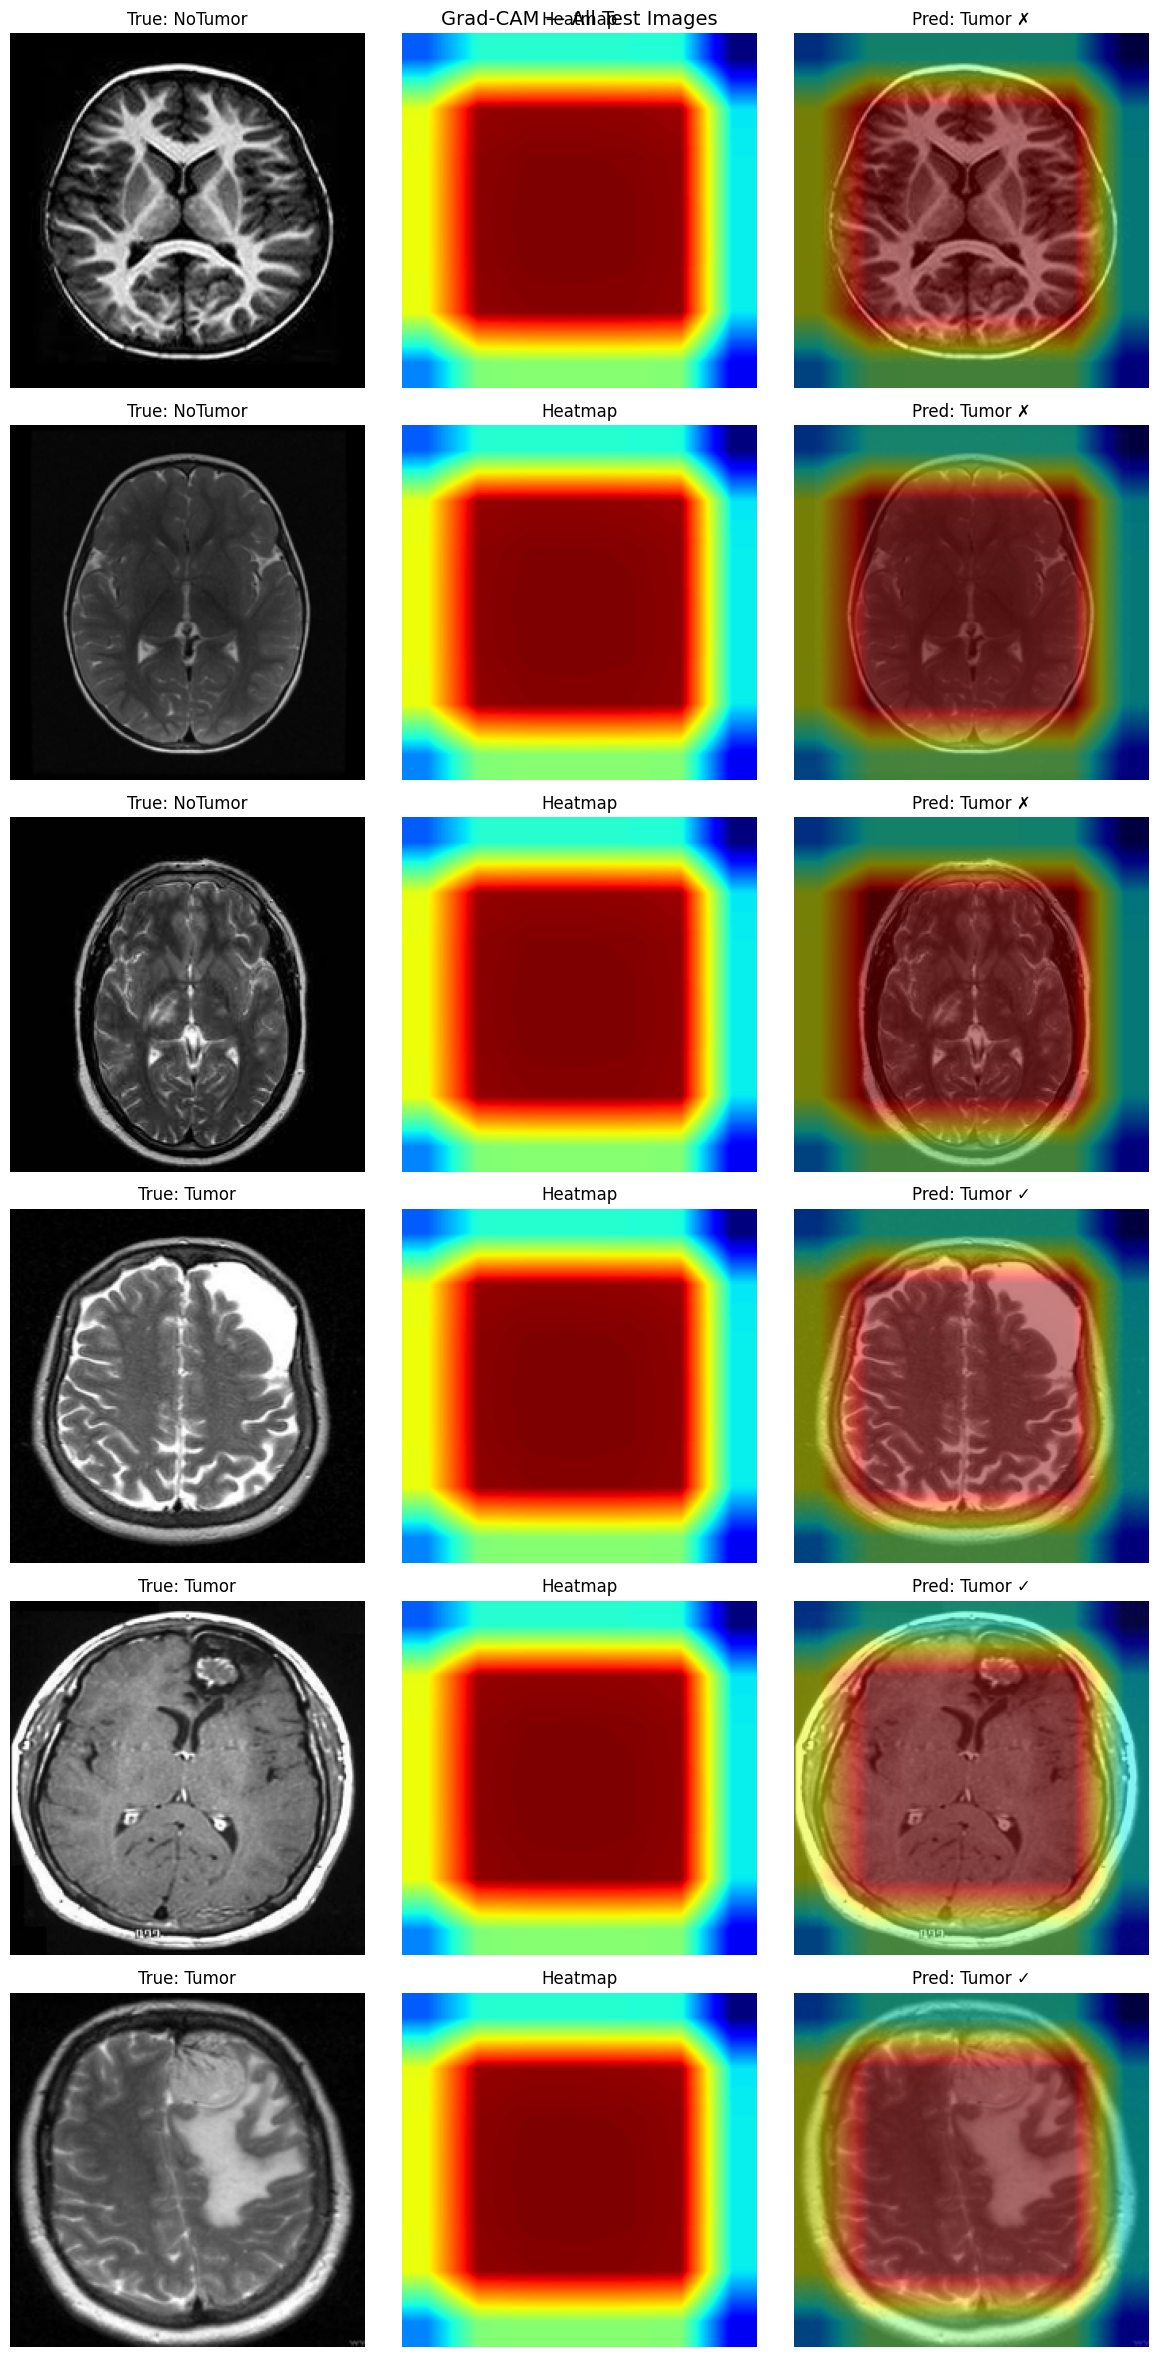

In [ ]:
# Grad-CAM on all test images
test_imgs = []
for class_name in train_dataset.classes:
    class_dir = os.path.join(test_data, class_name)
    if os.path.exists(class_dir):
        for fname in os.listdir(class_dir)[:3]:
            test_imgs.append((os.path.join(class_dir, fname), class_name))

fig, axes = plt.subplots(len(test_imgs), 3, figsize=(12, 4 * len(test_imgs)))
if len(test_imgs) == 1:
    axes = [axes]

for row, (img_path, true_label) in enumerate(test_imgs):
    orig, cam_map, overlay, pred_label = show_gradcam(img_path, gradcam, train_dataset.classes)
    correct = '✓' if pred_label == true_label else '✗'
    axes[row][0].imshow(orig);              axes[row][0].set_title(f'True: {true_label}');          axes[row][0].axis('off')
    axes[row][1].imshow(cam_map, cmap='jet'); axes[row][1].set_title('Heatmap');                   axes[row][1].axis('off')
    axes[row][2].imshow(overlay);           axes[row][2].set_title(f'Pred: {pred_label} {correct}'); axes[row][2].axis('off')

plt.suptitle('Grad-CAM — All Test Images', fontsize=14)
plt.tight_layout()
#plt.savefig('plots/gradcam_all_scratch.png', dpi=150)
plt.show()